# Set 7

## Dataset: FinancialPhraseBank

Source: Provided via course link (downloaded as CSV from Google Drive).

### Group Details:
Group No: 78

#### Group Members:
1.   SANJANA V KULKARNI - 2024DA04217
2.   BANDARU HAREESHA - 2024DA04089
3.   BHAVYA ARORA - 2023DA04058
4.   AVINASH GUPTA - 2023DC04310

---

### Objective


1.   Perform exploratory analysis and preprocessing on financial news headlines.
2.   Apply LDA to extract latent topics from the text corpus.
3.  Evaluate and visualize topics and syntactic dependencies for interpretability.

###How to run — Quick steps:

1.   Run the notebook top to bottom in Google Colab or Jupyter.
2.   Upload **all-data.csv** when prompted.
3.   The notebook performs EDA, preprocess text data, topic modeling, coherence evaluation, and visualization.
4.   Outputs are saved in the working directory.

###Notes/Assumptions:

1.   Only the first 2000 rows are used as per instructions.
2.   Topic modeling is performed on the **News Headline** column only.
3.   Number of topics is fixed at 10.
4.   Dependency parsing is shown for sentences with at least 10 words.


## Install and Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk gensim spacy pyLDAvis
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 25.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
#Import and Setup

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel

import spacy
from spacy import displacy

from google.colab import files
import io


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load Dataset

In [3]:
#Upload File , Load Dataset and Use first 2000 rows

uploaded = files.upload()
df = pd.read_csv('all-data.csv', encoding='latin-1')
df = df.head(2000)
df.head()




Saving all-data.csv to all-data (1).csv


,neutral,"According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing ."
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [5]:
df.columns = ['Sentiment', 'News Headline']
df.head()

,Sentiment,News Headline
0,neutral,Technopolis plans to develop in stages an area...
1,negative,The international electronic industry company ...
2,positive,With the new production plant the company woul...
3,positive,According to the company 's updated strategy f...
4,positive,FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


## Task -1 EDA & Preprocessing

### Sentiment Distribution

In [6]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts



,count
Sentiment,
positive,1032
neutral,901
negative,67


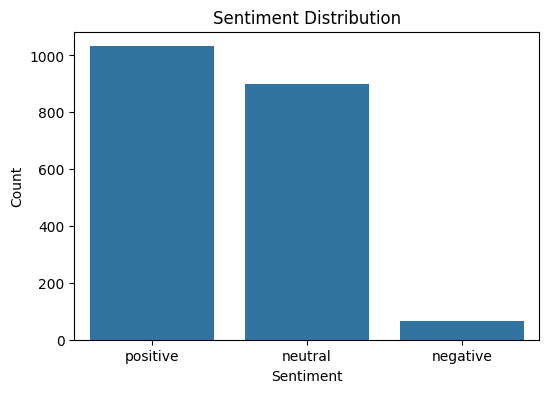

In [7]:
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution")
plt.ylabel("Count")
plt.savefig("sentiment_distribution.png", dpi=300)
plt.show()


### Text Statistics

In [8]:
df['char_length'] = df['News Headline'].apply(len)
df['word_count'] = df['News Headline'].apply(lambda x: len(x.split()))

df[['char_length','word_count']].describe()


,char_length,word_count
count,2000.000000,2000.000000
mean,135.624000,24.269500
std,55.816139,9.878951
min,9.000000,2.000000
25%,92.000000,17.000000
50%,128.500000,23.000000
75%,172.000000,30.000000
max,315.000000,81.000000


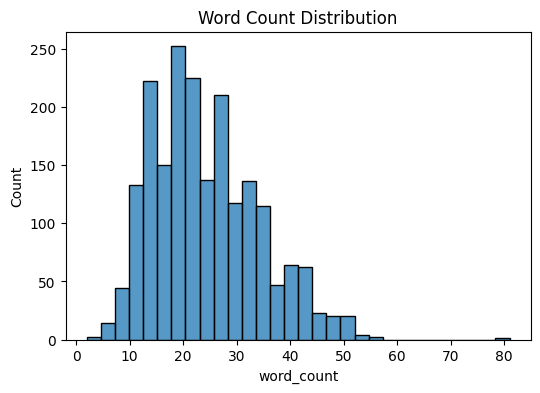

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(df['word_count'], bins=30)
plt.title("Word Count Distribution")
plt.savefig("text_length_distribution.png", dpi=300)
plt.show()


## Text Preprocessing

In [10]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return tokens

df['tokens'] = df['News Headline'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))


### Most Common Words

In [11]:
all_words = [word for tokens in df['tokens'] for word in tokens]
word_freq = Counter(all_words)

top_words = word_freq.most_common(10)
top_words


[('eur', 581),
 ('company', 376),
 ('said', 257),
 ('finnish', 227),
 ('sale', 225),
 ('million', 194),
 ('net', 174),
 ('service', 171),
 ('share', 169),
 ('profit', 165)]

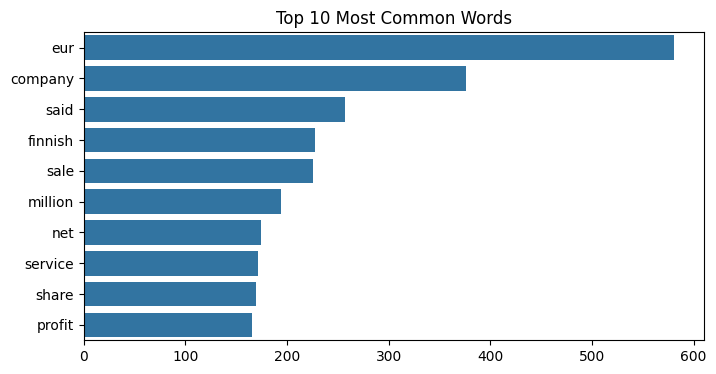

In [12]:
words, counts = zip(*top_words)
plt.figure(figsize=(8,4))
sns.barplot(x=list(counts), y=list(words))
plt.title("Top 10 Most Common Words")
plt.savefig("top_words.png", dpi=300)
plt.show()


## TASK 2 – LDA TOPIC MODELING (10 TOPICS)

In [13]:
vectorizer = CountVectorizer(max_df=0.9, min_df=10)
dtm = vectorizer.fit_transform(df['clean_text'])

lda = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    learning_method='online',
    max_iter=50
)

lda.fit(dtm)


LatentDirichletAllocation(learning_method='online', max_iter=50,
                          random_state=42)

In [14]:
feature_names = vectorizer.get_feature_names_out()

def print_topics(model, feature_names, n_top_words=5):
    topics = []
    for idx, topic in enumerate(model.components_):
        words = [feature_names[i] for i in topic.argsort()[:-n_top_words-1:-1]]
        topics.append(words)
        print(f"Topic {idx+1}: {', '.join(words)}")
    return topics

topics = print_topics(lda, feature_names)


Topic 1: service, customer, mobile, business, market
Topic 2: said, oyj, finnish, today, hel
Topic 3: share, increase, company, per, capital
Topic 4: product, finland, helsinki, finnish, awarded
Topic 5: sale, first, growth, quarter, result
Topic 6: new, also, company, plant, production
Topic 7: company, group, service, contract, project
Topic 8: million, percent, year, nokia, paper
Topic 9: eur, profit, net, sale, period
Topic 10: mln, euro, order, said, pct


## TASK 3 – COHERENCE SCORE (UMASS)

In [15]:
dictionary = Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

coherence_model = CoherenceModel(
    topics=topics,
    corpus=corpus,
    dictionary=dictionary,
    coherence='u_mass'
)

coherence_score = coherence_model.get_coherence()
coherence_score


np.float64(-3.076848845376663)

## TASK 4 – TOPIC VISUALIZATION

### Topic Distribution

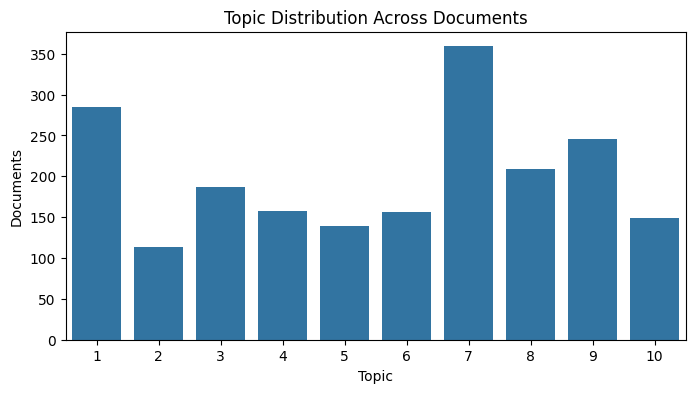

In [16]:
topic_probs = lda.transform(dtm)
dominant_topics = topic_probs.argmax(axis=1)

topic_dist = pd.Series(dominant_topics).value_counts().sort_index()

plt.figure(figsize=(8,4))
sns.barplot(x=topic_dist.index+1, y=topic_dist.values)
plt.title("Topic Distribution Across Documents")
plt.xlabel("Topic")
plt.ylabel("Documents")
plt.savefig("topic_distribution.png", dpi=300)
plt.show()


## TASK 5 – DEPENDENCY PARSER (2 SENTENCES ≥ 10 WORDS)

In [17]:
nlp = spacy.load("en_core_web_sm")

sentences = df[df['word_count'] >= 10]['News Headline'].sample(2, random_state=42).tolist()
sentences


['The terms of the financing were approved by the Annual General Meeting of the Company held on June 30 , 2010 .',
 "Before Kemira 's installation NordAlu was producing 3,500 tons of liquid and solid aluminum waste per year ."]

### Visualize Dependency Trees

In [18]:
for i, sent in enumerate(sentences, 1):
    doc = nlp(sent)
    svg = displacy.render(doc, style='dep', jupyter=False)
    with open(f"dependency_parse_sentence_{i}.html", "w", encoding="utf-8") as f:
        f.write(svg)
    display(displacy.render(doc, style='dep'))


None

None

## SAVE OUTPUT FILES

In [19]:
df.to_csv("preprocessed_financial_data.csv", index=False)


### Summary
This assignment explored financial news headlines using NLP techniques.
After preprocessing, LDA was applied to extract 10 latent topics and
topic coherence was evaluated. Topic distributions and dependency
parses were visualized to improve interpretability of results.
